<a href="https://colab.research.google.com/github/himanidas005/smart-academic-event-planner/blob/main/MINI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sentence-transformers scikit-learn pandas matplotlib


In [2]:
import pandas as pd

# Load uploaded dataset
df = pd.read_csv("/content/sample_data/student_feedback_survey_1000_rows (1).csv")

# Preview first 5 rows
df.head()

,student_id,department,current_skill_level,interest_description,preferred_mode,submission_date
0,1001,ME,Beginner,Interested in machine learning and AI fundamen...,Training,2026-04-08
1,1002,DS,Beginner,Interested in advanced SQL and database optimi...,Workshop,2026-04-19
2,1003,ECE,Beginner,Interested in machine learning and AI fundamen...,Workshop,2026-04-07
3,1004,DS,Advanced,Interested in Power BI and dashboard analytics,Workshop,2026-04-18
4,1005,DS,Advanced,Interested in data engineering and big data tools,Bootcamp,2026-04-08


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset Shape: (1000, 6)

Columns: ['student_id', 'department', 'current_skill_level', 'interest_description', 'preferred_mode', 'submission_date']


In [4]:
feedback_text = df["interest_description"].tolist()

print("Sample Feedback:")
print(feedback_text[:5])

Sample Feedback:
['Interested in machine learning and AI fundamentals', 'Interested in advanced SQL and database optimization', 'Interested in machine learning and AI fundamentals', 'Interested in Power BI and dashboard analytics', 'Interested in data engineering and big data tools']


In [5]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
embeddings = model.encode(feedback_text)

print("Embedding Shape:", embeddings.shape)

Embedding Shape: (1000, 384)


In [7]:
embeddings.shape

(1000, 384)

In [8]:
from sklearn.cluster import KMeans

In [9]:
num_clusters = 5

kmeans = KMeans(n_clusters=num_clusters, random_state=42)

df["cluster"] = kmeans.fit_predict(embeddings)

df.head()

,student_id,department,current_skill_level,interest_description,preferred_mode,submission_date,cluster
0,1001,ME,Beginner,Interested in machine learning and AI fundamen...,Training,2026-04-08,0
1,1002,DS,Beginner,Interested in advanced SQL and database optimi...,Workshop,2026-04-19,1
2,1003,ECE,Beginner,Interested in machine learning and AI fundamen...,Workshop,2026-04-07,0
3,1004,DS,Advanced,Interested in Power BI and dashboard analytics,Workshop,2026-04-18,1
4,1005,DS,Advanced,Interested in data engineering and big data tools,Bootcamp,2026-04-08,1


In [10]:
cluster_counts = df["cluster"].value_counts().sort_index()

print(cluster_counts)

cluster
0    196
1    514
2     90
3    107
4     93
Name: count, dtype: int64


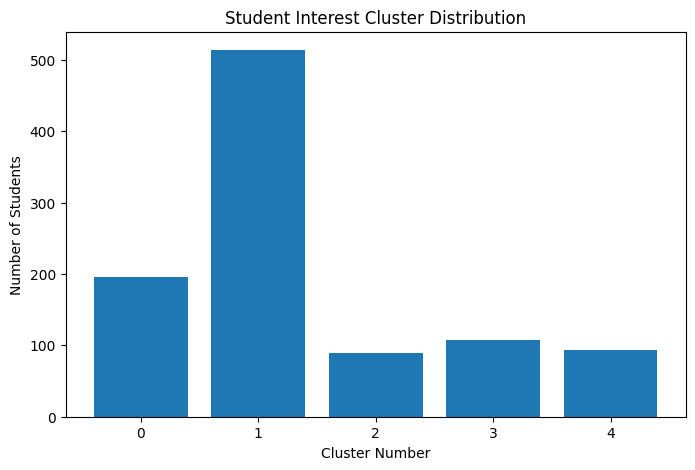

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel("Cluster Number")
plt.ylabel("Number of Students")
plt.title("Student Interest Cluster Distribution")
plt.xticks(cluster_counts.index)
plt.show()

In [12]:
majority_cluster = cluster_counts.idxmax()

print("Majority Demand Cluster:", majority_cluster)
print("Number of Students:", cluster_counts.max())

Majority Demand Cluster: 1
Number of Students: 514


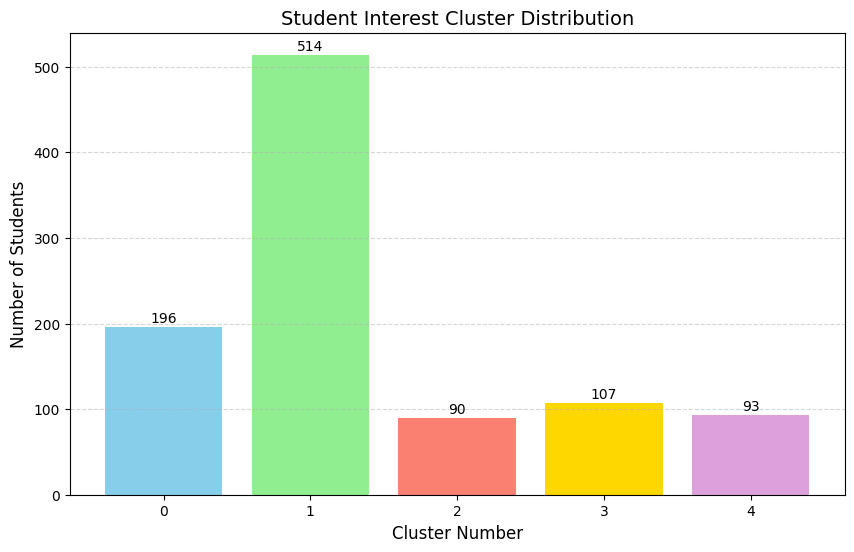

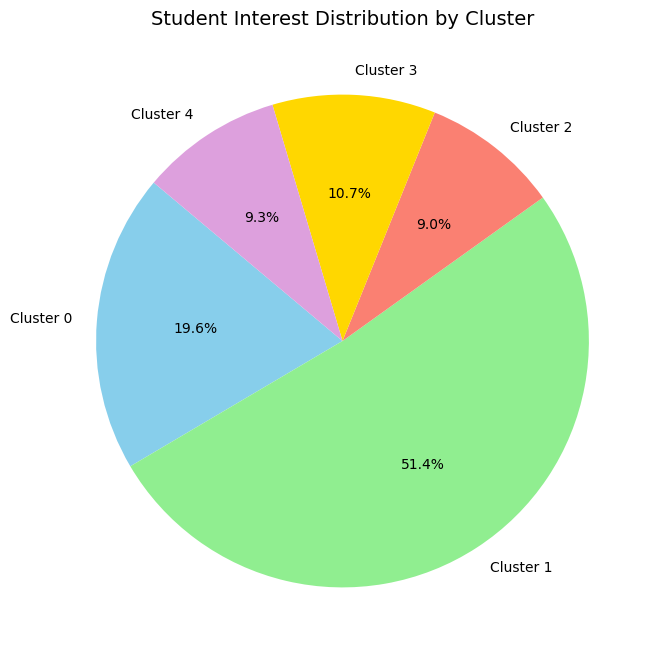

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

colors = ['skyblue', 'lightgreen', 'salmon', 'gold', 'plum']

bars = plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values,
    color=colors
)

plt.xlabel("Cluster Number", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.title("Student Interest Cluster Distribution", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, value in enumerate(cluster_counts.values):
    plt.text(i, value + 5, str(value), ha='center', fontsize=10)

plt.show()



plt.figure(figsize=(8,8))

colors = ['skyblue', 'lightgreen', 'salmon', 'gold', 'plum']

plt.pie(
    cluster_counts.values,
    labels=[f"Cluster {i}" for i in cluster_counts.index],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)

plt.title("Student Interest Distribution by Cluster", fontsize=14)
plt.show()


In [14]:
new_feedback = "I want to improve cloud computing and AWS skills"

print("New Student Comment:")
print(new_feedback)

New Student Comment:
I want to improve cloud computing and AWS skills


In [15]:
import sqlite3

conn = sqlite3.connect("student_feedback.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS feedback_table (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    comment TEXT,
    department TEXT,
    timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
)
""")

conn.commit()

print("Database and table created successfully")

Database and table created successfully


In [16]:
cursor.execute("""
INSERT INTO feedback_table (comment, department)
VALUES (?, ?)
""", (new_feedback, "CSE"))

conn.commit()

print("Feedback stored successfully")

Feedback stored successfully


In [17]:
cursor.execute("SELECT * FROM feedback_table")
rows = cursor.fetchall()

for row in rows:
    print(row)

(1, 'I want to improve cloud computing and AWS skills', 'CSE', '2026-04-10 04:56:04')


In [18]:
db_df = pd.read_sql_query("SELECT * FROM feedback_table", conn)

db_df

,id,comment,department,timestamp
0,1,I want to improve cloud computing and AWS skills,CSE,2026-04-10 04:56:04


In [19]:
cluster_groups = df.groupby("cluster")["interest_description"].apply(list)

for cluster_num, comments in cluster_groups.items():
    print(f"\nCluster {cluster_num}:")
    for comment in comments[:3]:
        print("-", comment)


Cluster 0:
- Interested in machine learning and AI fundamentals
- Interested in machine learning and AI fundamentals
- Interested in deep learning and neural networks

Cluster 1:
- Interested in advanced SQL and database optimization
- Interested in Power BI and dashboard analytics
- Interested in data engineering and big data tools

Cluster 2:
- Interested in DSA and coding interview preparation
- Interested in DSA and coding interview preparation
- Interested in DSA and coding interview preparation

Cluster 3:
- Interested in cloud computing and AWS
- Interested in cloud computing and AWS
- Interested in cloud computing and AWS

Cluster 4:
- Interested in MERN stack web development
- Interested in MERN stack web development
- Interested in MERN stack web development


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
def extract_cluster_keywords(comments, top_n=5):
    vectorizer = TfidfVectorizer(stop_words='english')
    X = vectorizer.fit_transform(comments)

    scores = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    top_indices = scores.argsort()[-top_n:][::-1]

    top_keywords = [words[i] for i in top_indices]

    return top_keywords

In [22]:
generated_workshops = {}

cluster_keywords = {cluster_num: extract_cluster_keywords(comments) for cluster_num, comments in cluster_groups.items()}

for cluster_num, keywords in cluster_keywords.items():
    workshop_name = "Workshop on " + " ".join([word.capitalize() for word in keywords[:3]])

    generated_workshops[cluster_num] = workshop_name

    print(f"Cluster {cluster_num}: {workshop_name}")

Cluster 0: Workshop on Learning Interested Networks
Cluster 1: Workshop on Data Interested Visualization
Cluster 2: Workshop on Preparation Interview Interested
Cluster 3: Workshop on Interested Computing Cloud
Cluster 4: Workshop on Web Stack Mern


In [23]:
recommended_workshop = generated_workshops[majority_cluster]

print("Final Recommended Event:")
print(recommended_workshop)

Final Recommended Event:
Workshop on Data Interested Visualization


## Module 5: Analytics Dashboard and Final Recommendation
### Final AI-Based Event Planning Output

In [24]:
print("=" * 70)
print(" SMART ACADEMIC EVENT PLANNING DASHBOARD ")
print("=" * 70)

print(f"\nTotal Student Responses Analysed : {len(df)}")
print(f"Total Clusters Identified        : {num_clusters}")
print(f"Majority Demand Cluster          : {majority_cluster}")
print(f"Recommended Workshop            : {recommended_workshop}")

print("=" * 70)

 SMART ACADEMIC EVENT PLANNING DASHBOARD 

Total Student Responses Analysed : 1000
Total Clusters Identified        : 5
Majority Demand Cluster          : 1
Recommended Workshop            : Workshop on Data Interested Visualization


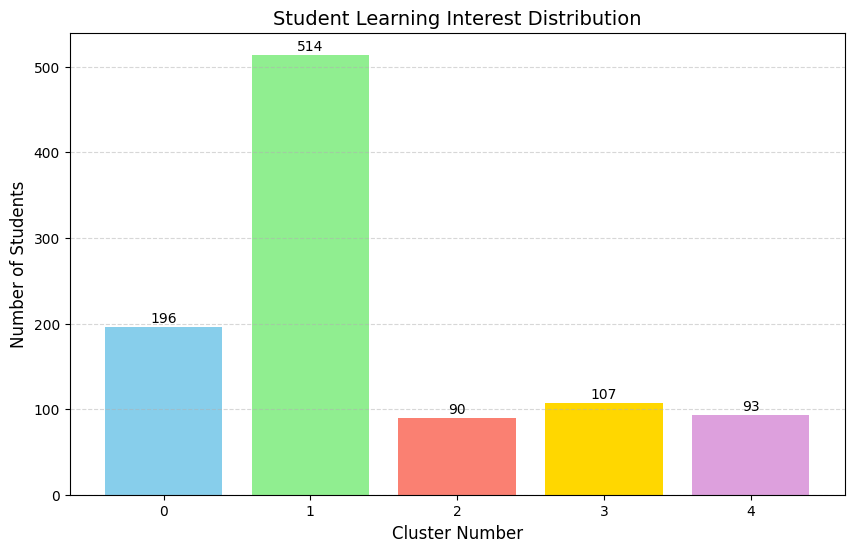

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

colors = ['skyblue', 'lightgreen', 'salmon', 'gold', 'plum']

bars = plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values,
    color=colors
)

plt.title("Student Learning Interest Distribution", fontsize=14)
plt.xlabel("Cluster Number", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, value in enumerate(cluster_counts.values):
    plt.text(i, value + 5, str(value), ha='center')

plt.show()

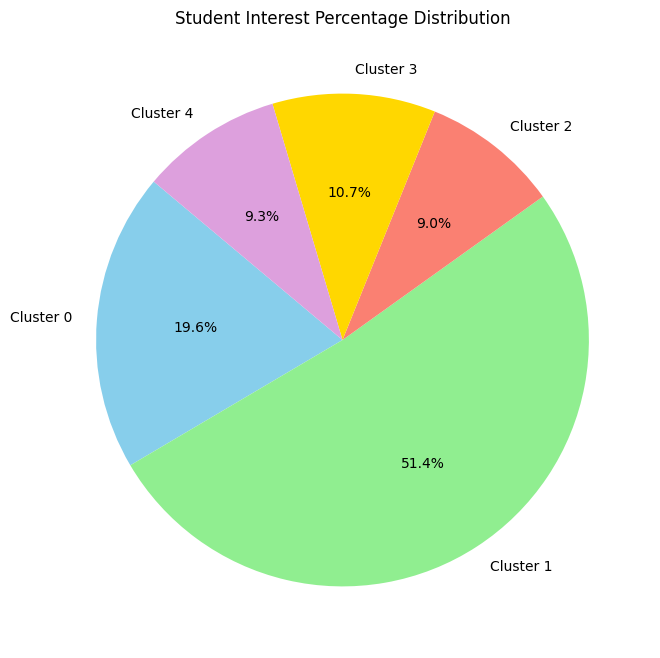

In [26]:
plt.figure(figsize=(8,8))

plt.pie(
    cluster_counts.values,
    labels=[f"Cluster {i}" for i in cluster_counts.index],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)

plt.title("Student Interest Percentage Distribution")
plt.show()

In [27]:
print("\n" + "=" * 70)
print(" FINAL EVENT RECOMMENDATION ")
print("=" * 70)

print(f"""
Based on semantic clustering and majority student demand,
the recommended academic event is:

>>> {recommended_workshop}

This event should be prioritized for the upcoming semester.
""")


 FINAL EVENT RECOMMENDATION 

Based on semantic clustering and majority student demand,
the recommended academic event is:

>>> Workshop on Data Interested Visualization

This event should be prioritized for the upcoming semester.

